In [1]:
import gc, torch
torch.cuda.empty_cache()
gc.collect()

11

In [2]:
import plotting as plt
from data_utils import load_or_create_vocabulary
from train      import run_training
from inference  import reconstruct_smiles_table
import os
import data_utils as du

/home/mmondol/anaconda3/envs/chemoinf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
cfg = dict(
    # ---------------- data ----------------
    train_files = [
        "/home/mmondol/VAE_LLM/Data/Train_1.csv",
        "/home/mmondol/VAE_LLM/Data/Train_2.csv",
        "/home/mmondol/VAE_LLM/Data/Train_3.csv"],
    val_files   = ["/home/mmondol/VAE_LLM/Data/Valid_1.csv"],
    test_files  = ["/home/mmondol/VAE_LLM/Data/Test.csv"],
    dye_files   = ["/home/mmondol/VAE_LLM/Data/dye.csv"],

    # Paper max length is 56, but keep yours for fair comparison
    seq_length  = 160,

    n_train     = 250000,
    n_val       = 80000,

    # ---------------- model (paper-aligned) ----------------
    d_model     = 512,
    latent_dim  = 64,
    enc_heads   = 8,
    dec_heads   = 8,
    enc_layers  = 7,
    dec_layers  = 7,
    ff_dim      = 1024,
    dropout     = 0.05,

    # graph feature dims (your implementation)
    node_feat_dim = len(du.ATOM_LIST) + 3,
    edge_feat_dim = 6,

    # special token indices
    pad_idx     = 0,
    sos_idx     = 2,
    eos_idx     = 3,

    # -------------- optimization (paper-aligned) --------------
    batch       = 128,      
    lr          = 1e-5,
    weight_decay= 1e-4,

    epochs      = 100,
    
    early_stop  = 10,
    early_stop_min_delta = 1e-4,
    clip_grad   = 1.0,

    # -------------- schedules --------------
    kl_anneal   = 15,
    kl_max      = 0.02,

    # -------- regularization tweaks --------
    label_smoothing = 0.00,
    corruption_p    = 0.00,

    # -------- validation / decoding --------
    beam_every  = 5,
    beam_size   = 5,

    # ---------------- I/O ----------------
    save_dir    = "./checkpoints",
    save_every  = 10,

    # -------- optional LR scheduler ------
    plateau = dict(mode="min", factor=0.3, patience=3, verbose=True, min_lr=0.0, threshold=1e-4)
    )

In [4]:
all_csvs = cfg["train_files"] + cfg["val_files"] + cfg["test_files"] + cfg["dye_files"]
token_to_idx, idx_to_token = load_or_create_vocabulary(all_csvs, cache_path="vocab.json", test_smiles=None)

assert token_to_idx["<PAD>"] == cfg["pad_idx"], "PAD index mismatch with cached vocab"
assert token_to_idx["<SOS>"] == cfg["sos_idx"], "SOS index mismatch with cached vocab"
assert token_to_idx["<EOS>"] == cfg["eos_idx"], "EOS index mismatch with cached vocab"
print("Vocab size:", len(token_to_idx))
print(token_to_idx)
print("Special tokens:")
print("PAD:", token_to_idx["<PAD>"])
print("SOS:", token_to_idx["<SOS>"])
print("EOS:", token_to_idx["<EOS>"])

[vocab] loaded cached vocabulary from vocab.json (69 tokens)
Vocab size: 69
{'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3, 'O': 4, '=': 5, 'C': 6, '1': 7, 'N': 8, '[C@@H]': 9, '[NH+]': 10, '(': 11, 'c': 12, '2': 13, '(O)': 14, ')': 15, '(=O)': 16, 'S': 17, '3': 18, 'n': 19, '-': 20, '[C@H]': 21, '4': 22, 's': 23, '(C)': 24, '[': 25, ']': 26, '(F)': 27, 'F': 28, '#': 29, '[nH]': 30, '[nH+]': 31, '(Cl)': 32, 'o': 33, '[NH2+]': 34, '@': 35, 'H': 36, '+': 37, '(Br)': 38, '[O-]': 39, 'Cl': 40, '[N-]': 41, '/': 42, '\\': 43, 'Br': 44, '5': 45, '(I)': 46, 'I': 47, '6': 48, '[N+]': 49, '[n+]': 50, '[o+]': 51, '7': 52, 'p': 53, '.': 54, 'P': 55, '8': 56, '9': 57, 'A': 58, 'B': 59, '[Na+]': 60, '[Zn]': 61, '[Co+2]': 62, '[Cd+2]': 63, '[Cl-]': 64, '[Cr+3]': 65, '[B-]': 66, '[C+]': 67, '[Pb+2]': 68}
Special tokens:
PAD: 0
SOS: 2
EOS: 3


In [5]:
model, history = run_training(cfg, token_to_idx, idx_to_token)

Using device: cuda
Visible CUDA devices: 1
Trainable params: 25979077


/home/mmondol/VAE_LLM/LSTM_VAE_Paper/train.py:177: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/home/mmondol/anaconda3/envs/chemoinf/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/home/mmondol/VAE_LLM/LSTM_VAE_Paper/train.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/home/mmondol/anaconda3/envs/chemoinf/lib/python3.12/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/home/mmondol/VAE_LLM/LSTM_VAE_Paper/train.py:84: FutureWarning: `torch.cuda.amp.autocast(args...)`

Epoch  1: train 1.4475/0.571  val(tf) 1.0215/0.673  KL 0.00
Epoch  2: train 0.9736/0.682  val(tf) 0.8133/0.729  KL 0.00
Epoch  3: train 0.8216/0.723  val(tf) 0.6891/0.764  KL 0.00
Epoch  4: train 0.7254/0.752  val(tf) 0.6082/0.790  KL 0.01
Epoch  5: train 0.6580/0.774  val(tf) 0.5481/0.811  beam_acc 0.279  valid 0.832  lev 22.35  KL 0.01
Epoch  6: train 0.6083/0.791  val(tf) 0.5065/0.826  KL 0.01
Epoch  7: train 0.5684/0.805  val(tf) 0.4770/0.836  KL 0.01
Epoch  8: train 0.5363/0.817  val(tf) 0.4465/0.848  KL 0.01
Epoch  9: train 0.5089/0.827  val(tf) 0.4194/0.858  KL 0.01
Epoch 10: train 0.4854/0.835  val(tf) 0.4003/0.865  beam_acc 0.369  valid 0.893  lev 18.67  KL 0.01
Epoch 11: train 0.4653/0.843  val(tf) 0.3808/0.873  KL 0.01
Epoch 12: train 0.4474/0.850  val(tf) 0.3652/0.879  KL 0.02
Epoch 13: train 0.4319/0.856  val(tf) 0.3516/0.884  KL 0.02
Epoch 14: train 0.4177/0.861  val(tf) 0.3393/0.889  KL 0.02
Epoch 15: train 0.4052/0.866  val(tf) 0.3286/0.894  beam_acc 0.443  valid 0.913 

[plot] saved to ./checkpoints/training_curves.png


(<Figure size 1500x800 with 6 Axes>,
 array([[<Axes: title={'center': 'Loss (TF)'}, ylabel='CE+KL'>,
         <Axes: title={'center': 'Token Acc (TF)'}>,
         <Axes: title={'center': 'Token Acc (Beam)'}>],
        [<Axes: title={'center': 'Validity Ratio (Beam)'}, xlabel='epoch'>,
         <Axes: title={'center': 'Levenshtein (Beam)'}, xlabel='epoch'>,
         <Axes: xlabel='epoch'>]], dtype=object))

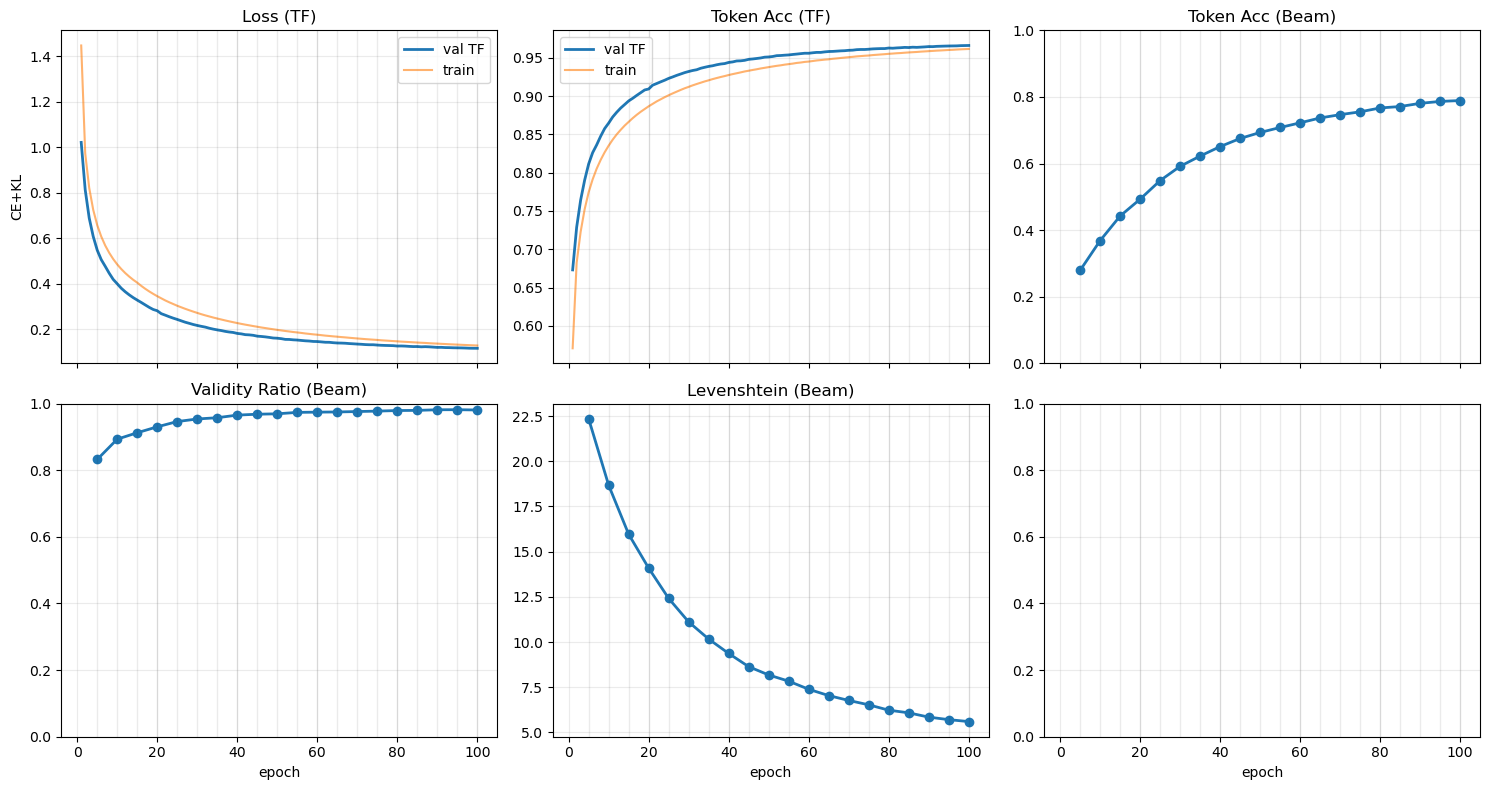

In [6]:
plt.plot_training_curves(history, beam_every=cfg["beam_every"], save_path=os.path.join(cfg["save_dir"], "training_curves.png"))

In [7]:
import torch.nn as nn
m = model.module if isinstance(model, nn.DataParallel) else model
device = next(m.parameters()).device

df_rec = reconstruct_smiles_table(
    smiles_list=None,
    test_csv=cfg["test_files"][0],
    model=m,
    token_to_idx=token_to_idx,
    idx_to_token=idx_to_token,
    seq_length=cfg["seq_length"],
    pad_idx=cfg["pad_idx"],
    sos_idx=cfg["sos_idx"],
    eos_idx=cfg["eos_idx"],
    device=device,
    mode="beam",
    beam_size=cfg["beam_size"])

df_rec.tail(20)

/home/mmondol/anaconda3/envs/chemoinf/lib/python3.12/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


,input,reconstructed,valid,lev
250,CC(C)=CC(=O)NCc1cc[nH+]c(N2CCO[C@@H](C)C2)c1,CC(C)CCO[C@@H](C)CNC(=O)Cc1cc[nH+]c(N2CCNC(=O)...,yes,22
251,[NH3+]CC1([C@H](O)c2ccccc2OC(F)F)CCC1,[NH3+]C[C@@](O)(c1ccccc1OC(F)F)C1CCC1,yes,9
252,COC(=O)c1nn(CC(=O)NCCc2ccc(OC)c(OC)c2)c(=O)c2n...,COC(=O)c1nn(CC(=O)NCCc2ccc(OC)c(OC)c2)c(=O)c2n...,yes,0
253,Cc1cnc(NC(=O)N[C@@H](C)c2ccc(S(=O)(=O)N(C)C)cc...,Cc1cnc(NC(=O)N[C@H](C)c2ccc(S(=O)(=O)N(C)C)cc2)s1,yes,1
254,CCOC(=O)c1cnn([C@H]2CCCN(C(=O)Nc3cccc(N(C)CC)c...,CCOC(=O)c1cnn([C@@H]2CCCN(C(=O)Nc3cccc(N(C)CC)...,yes,1
255,CCCCNC(=O)[C@H]1[C@H]2C=C[C@]3(CN(c4cc(C)on4)C...,CCCCNC(=O)[C@@H]1[C@@H]2C=C[C@@]3(CN(c4cc(C)on...,yes,4
256,CC(C)[C@@H]1CN(Cc2c[nH]nc2-c2ccc(Cl)cc2)C[C@H]...,CC(C)[C@@H]1CN(Cc2cn[nH]c2-c2ccc(Cl)cc2)C[C@H]...,yes,2
257,CC(C)N(Cc1ccc(Cl)nc1)C[C@H]1CCCCO1,CC(C)N(Cc1ccc(Cl)nc1)C[C@@H]1CCCCO1,yes,1
258,c1ccc(-c2nc(CN3CCC[C@H]3c3ccccc3)no2)cc1,c1ccc(-c2nc(CN3CCC[C@@H]3c3ccccc3)no2)cc1,yes,1
259,CC(C)C[C@@H](CN)C(=O)NCCCC(=O)[O-],CC(C)C[C@@H](CN)C(=O)NCCCC(=O)[O-],yes,0


In [8]:

# ------------------------------------------------------------------
# 1.  Token-level accuracy (micro-average over SMILES tokens)
# ------------------------------------------------------------------
def token_accuracy_row(gold, pred):
    g = du.tokenize_smiles(gold)
    p = du.tokenize_smiles(pred)
    L = min(len(g), len(p))
    if L == 0:                      # degenerate empty case
        return 0, 0
    correct = sum(gi == pi for gi, pi in zip(g[:L], p[:L]))
    total   = L
    return correct, total

tot_corr = tot_tok = 0
for g, p in zip(df_rec["input"], df_rec["reconstructed"]):
    c, t = token_accuracy_row(g, p)
    tot_corr += c
    tot_tok  += t

beam_token_acc = tot_corr / tot_tok if tot_tok else 0.0
print(f"Token level test accuracy (beam): {beam_token_acc:.4f}")

# ------------------------------------------------------------------
# 2.  Sequence-level (exact-match) accuracy
# ------------------------------------------------------------------
exact_match_acc = (df_rec["input"] == df_rec["reconstructed"]).mean()
print(f"Exact SMILES match accuracy (beam): {exact_match_acc:.4f}")

Token level test accuracy (beam): 0.7908
Exact SMILES match accuracy (beam): 0.3481


In [9]:
df_rec = reconstruct_smiles_table(
    smiles_list=None,
    test_csv=cfg["dye_files"][0],
    model=m,
    token_to_idx=token_to_idx,
    idx_to_token=idx_to_token,
    seq_length=cfg["seq_length"],
    pad_idx=cfg["pad_idx"],
    sos_idx=cfg["sos_idx"],
    eos_idx=cfg["eos_idx"],
    device=device,
    mode="beam",
    beam_size=cfg["beam_size"])

df_rec.head(40)

/home/mmondol/anaconda3/envs/chemoinf/lib/python3.12/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


,input,reconstructed,valid,lev
0,O=S1(=O)OC(c2ccc(O)c(Cl)c2)(c2ccc(O)c(Cl)c2)c2...,O=S1(=O)c2ccccc2[C@@](O)(c2ccc(O)c(Cl)c2)Oc2cc...,yes,18
1,O=S1(=O)OC(c2ccc(O)c(Br)c2)(c2ccc(O)c(Br)c2)c2...,O=S(=O)(c1ccc(O)c(Br)c1)c1ccc2c(O)cccc2c1O,yes,19
2,Cc1cc(C2(c3cc(C)c(O)c(Br)c3)OS(=O)(=O)c3ccccc3...,Cc1cc([C@@H]2Oc3ccccc3S(=O)(=O)N2)cc(C)c1O,yes,28
3,O=S1(=O)OC(c2ccc(O)cc2)(c2ccc(O)cc2)c2ccccc21,O=S1(=O)c2ccccc2[C@@](O)(c2ccc(O)cc2)Oc2ccc(O)...,yes,16
4,Cc1cc(O)ccc1C1(c2ccc(O)cc2C)OS(=O)(=O)c2ccccc21,Cc1ccc([C@@]2(O)c3ccccc3Oc3ccc(O)cc3S2)c(O)c1,yes,31
5,CN(C)c1ccc(N=Nc2ccccc2)cc1,CN(C)c1ccc(NCN(c2ccccc2)c2ccc(N)cc2)cc1,yes,14
6,CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1,CN(C)c1ccc(Nc2ccc(S(=O)(=O)[O-])cc2)cc1,yes,2
7,c1ccc(-c2cc3nc4cccc(-c5ccccc5-c5ccccc5)c4nc3cc...,c1ccc(-c2[nH]c3ccccc3c2-c2ccc3ccccc3c2)cc1,yes,26
8,CN(C)c1ccc(N=Nc2ccccc2C(=O)O)cc1,CN(C)c1ccc(Nc2ccccc2C(=O)[O-])cc1,yes,5
9,O=C1OC2(c3ccc(O)cc3Oc3cc(O)ccc32)c2ccccc21,O=C1Oc2ccc(O)cc2[C@@]12Oc1ccccc1-c1ccc(O)cc12,yes,24


In [10]:
tot_corr = tot_tok = 0
for g, p in zip(df_rec["input"], df_rec["reconstructed"]):
    c, t = token_accuracy_row(g, p)
    tot_corr += c
    tot_tok  += t

beam_token_acc = tot_corr / tot_tok if tot_tok else 0.0
print(f"Token level test accuracy for Dye SMILES (beam): {beam_token_acc:.4f}")

# ------------------------------------------------------------------
# 2.  Sequence-level (exact-match) accuracy
# ------------------------------------------------------------------
exact_match_acc = (df_rec["input"] == df_rec["reconstructed"]).mean()
print(f"Exact SMILES match accuracy for Dye SMILES (beam): {exact_match_acc:.4f}")

Token level test accuracy for Dye SMILES (beam): 0.4898
Exact SMILES match accuracy for Dye SMILES (beam): 0.0588
